In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime

In [2]:
customer_df = pd.read_csv("..\\Cleaned_Dataset\\cleaned_customer.csv")

geolocation_df = pd.read_csv("..\\Cleaned_Dataset\\cleaned_geolocation.csv")

order_item_df = pd.read_csv("..\\Cleaned_Dataset\\cleaned_order_item.csv")

order_payment_df = pd.read_csv("..\\Cleaned_Dataset\\cleaned_order_payment.csv")

order_reviews_df = pd.read_csv("..\\Cleaned_Dataset\\cleaned_order_reviews.csv")

orders_df = pd.read_csv("..\\Cleaned_Dataset\\cleaned_order.csv")

products_df = pd.read_csv("..\\Cleaned_Dataset\\cleaned_products.csv")

seller_df = pd.read_csv("..\\Cleaned_Dataset\\cleaned_seller.csv")

In [3]:
df= pd.merge(order_item_df,orders_df, on='order_id', how='left')

df = pd.merge(df,order_payment_df, on='order_id',how='left')

df = pd.merge(df,customer_df,on='customer_id',how='left')

df = pd.merge(df,seller_df,on='seller_id',how='left')

df = pd.merge(df,products_df,on='product_id',how='left')

In [4]:
df.to_csv("..\\Cleaned_Dataset\\olist_retail_merged.csv",index=False)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 117604 entries, 0 to 117603
Data columns (total 35 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       117604 non-null  str    
 1   order_item_id                  117604 non-null  int64  
 2   product_id                     117604 non-null  str    
 3   seller_id                      117604 non-null  str    
 4   shipping_limit_date            117604 non-null  str    
 5   price                          117604 non-null  float64
 6   freight_value                  117604 non-null  float64
 7   customer_id                    117604 non-null  str    
 8   order_status                   117604 non-null  str    
 9   order_purchase_timestamp       117604 non-null  str    
 10  order_approved_at              117589 non-null  str    
 11  order_delivered_carrier_date   116359 non-null  str    
 12  order_delivered_customer_date  115045 non

In [26]:
df.isnull().sum()

order_id                            0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1245
order_delivered_customer_date    2559
order_estimated_delivery_date       0
delivery_missing_flag               0
payment_sequential                  3
payment_type                        3
payment_installments                3
payment_value                       3
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
seller_zip_code_prefix              0
seller_city                         0
seller_state                        0
product_cate

In [7]:
summary=df.describe(percentiles=[0.25,0.50,0.75,0.90,0.99]).T
summary['IQR'] = summary['75%'] - summary['25%']
summary

,count,mean,std,min,25%,50%,75%,90%,99%,max,IQR
order_item_id,117604.0,1.195920,0.697721,1.00,1.00,1.00,1.00,2.00,4.0000,21.00,0.00
price,117604.0,120.822849,184.477367,0.85,39.90,74.90,134.90,229.90,896.9595,6735.00,95.00
freight_value,117604.0,20.045551,15.861351,0.00,13.08,16.29,21.19,34.15,85.1600,409.68,8.11
delivery_missing_flag,117604.0,0.021827,0.146121,0.00,0.00,0.00,0.00,0.00,1.0000,1.00,0.00
payment_sequential,117601.0,1.093528,0.726692,1.00,1.00,1.00,1.00,1.00,3.0000,29.00,0.00
payment_installments,117601.0,2.939507,2.774200,1.00,1.00,2.00,4.00,8.00,10.0000,24.00,3.00
payment_value,117601.0,172.686752,267.592290,0.00,60.87,108.21,189.26,337.50,1221.2800,13664.08,128.39
customer_zip_code_prefix,117604.0,35051.271385,29820.387420,1003.00,11310.00,24315.00,58600.00,86800.00,97572.9700,99990.00,47290.00
seller_zip_code_prefix,117604.0,24442.886483,27573.802989,1001.00,6429.00,13660.00,28035.00,85603.00,93542.0000,99730.00,21606.00
product_name_lenght,117604.0,48.063093,11.536581,0.00,42.00,51.00,57.00,59.00,63.0000,76.00,15.00


In [8]:
df.dtypes

order_id                             str
order_item_id                      int64
product_id                           str
seller_id                            str
shipping_limit_date                  str
price                            float64
freight_value                    float64
customer_id                          str
order_status                         str
order_purchase_timestamp             str
order_approved_at                    str
order_delivered_carrier_date         str
order_delivered_customer_date        str
order_estimated_delivery_date        str
delivery_missing_flag              int64
payment_sequential               float64
payment_type                         str
payment_installments             float64
payment_value                    float64
customer_unique_id                   str
customer_zip_code_prefix           int64
customer_city                        str
customer_state                       str
seller_zip_code_prefix             int64
seller_city     

In [9]:
datetime_col = [col for col in df.columns if 'date' in col.lower()]

In [10]:
for col in datetime_col:
    df[col]=pd.to_datetime(df[col])

In [11]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_approved_at']  = pd.to_datetime(df['order_approved_at'])

## Sales & Financial Performance

***Objective***
To evaluate the company's revenue growth, profitability, and payment dynamics to identify high-performing segments and areas for financial optimization.

### Q1. What is total revenue(Gross Sales) generated overtime


In [12]:
df.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value', 'customer_id',
       'order_status', 'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'delivery_missing_flag',
       'payment_sequential', 'payment_type', 'payment_installments',
       'payment_value', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state', 'seller_zip_code_prefix',
       'seller_city', 'seller_state', 'product_category_name',
       'product_name_lenght', 'product_description_lenght',
       'product_photos_qty', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm',
       'product_category_name_english'],
      dtype='str')

In [13]:
valid_Sales=df[~df['order_status'].isin(['canceled','unavailable'])]

In [14]:
valid_Sales['order_purchase_timestamp_in_Y_M']=valid_Sales['order_purchase_timestamp'].dt.to_period('M')

In [15]:
Total_Revenue_Overtime = valid_Sales.groupby(by='order_purchase_timestamp_in_Y_M').agg({'price':'sum'})

In [16]:
Total_Revenue_Overtime

,price
order_purchase_timestamp_in_Y_M,
2016-09,207.86
2016-10,45941.87
2016-12,10.90
2017-01,128423.39
2017-02,258410.19
2017-03,390448.06
2017-04,385700.17
2017-05,542369.71
2017-06,449909.42


<Axes: xlabel='order_purchase_timestamp_in_Y_M', ylabel='price'>

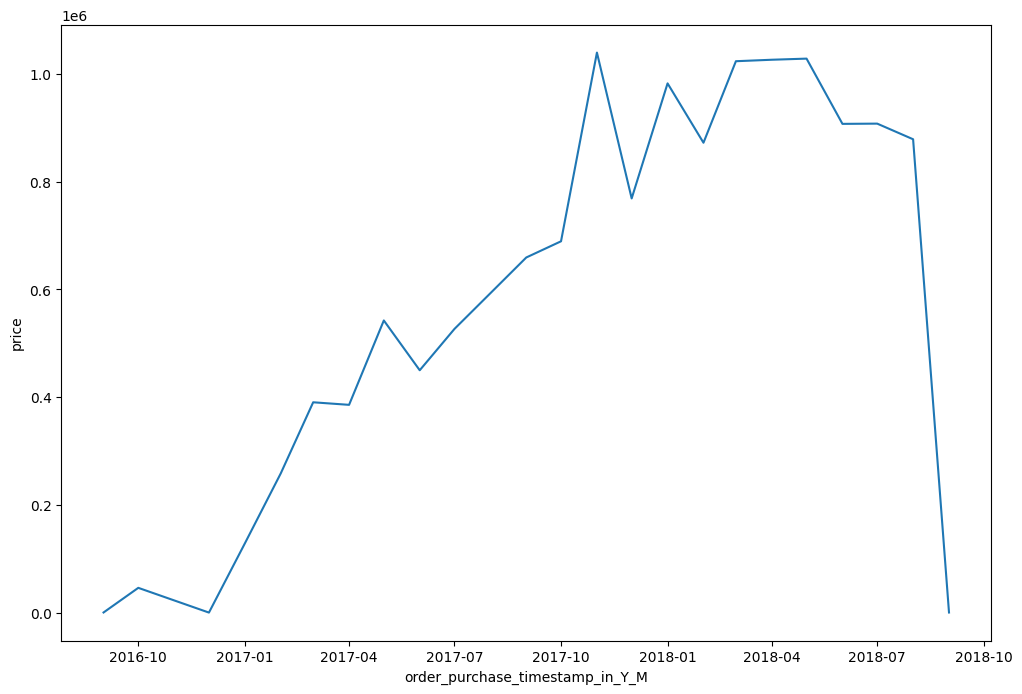

In [17]:
plt.figure(figsize=(12,8))
sns.lineplot(data=Total_Revenue_Overtime,x=Total_Revenue_Overtime.index.to_timestamp(),y='price')


**Observation:**
* Massive spike on **Nov 2017**
* The Sharp drop in **Late 2018**

### Q2 Which product categories bring in the highest revenue versus the highest freight costs?


In [18]:
highest_revenue_vs_freight_cost = valid_Sales.groupby('product_category_name_english').agg({
    'price': 'sum',
    'freight_value': 'sum' 
    }
)

In [19]:
highest_revenue_vs_freight_cost.sort_values(by='price',ascending=False).head(10)

,price,freight_value
product_category_name_english,,
health_beauty,1294329.27,187768.67
watches_gifts,1246322.83,103906.85
bed_bath_table,1091526.40,217462.14
sports_leisure,1015652.39,173409.11
computers_accessories,934645.27,152480.89
furniture_decor,762704.74,180895.53
housewares,659881.24,153163.95
cool_stuff,645140.13,87073.36
auto,610618.13,95046.27


Text(0.5, 1.0, 'Top 10 Highest Revenue VS Highest Freight Cost')

<Figure size 1600x2000 with 0 Axes>

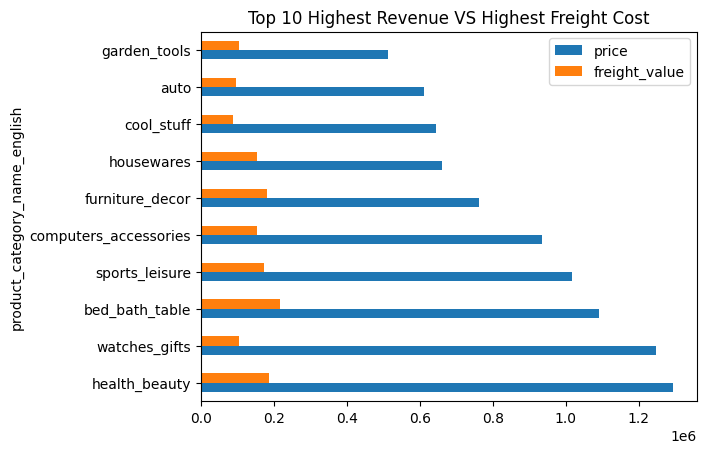

In [20]:
plt.figure(figsize=(16,20))
highest_revenue_vs_freight_cost.sort_values(by='price',ascending=False).head(10).plot(kind='barh')
plt.title('Top 10 Highest Revenue VS Highest Freight Cost')

### Q3. Which categories generate the highest revenue in 2018?

In [21]:
Sales_in_2018 = valid_Sales[valid_Sales['order_purchase_timestamp'].dt.year == 2018]
Sales_in_2018

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,order_purchase_timestamp_in_Y_M
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor,2018-01
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery,2018-08
7,000576fe39319847cbb9d288c5617fa6,1,557d850972a7d6f792fd18ae1400d9b6,5996cddab893a4652a15592fb58ab8db,2018-07-10 12:30:45,810.00,70.75,9ed5e522dd9dd85b4af4a077526d8117,delivered,2018-07-04 12:08:27,...,ferramentas_jardim,39.0,1310.0,3.0,13805.0,35.0,75.0,45.0,garden_tools,2018-07
8,0005a1a1728c9d785b8e2b08b904576c,1,310ae3c140ff94b03219ad0adc3c778f,a416b6a846a11724393025641d4edd5e,2018-03-26 18:31:29,145.95,11.65,16150771dfd4776261284213b89c304e,delivered,2018-03-19 18:40:33,...,beleza_saude,59.0,493.0,1.0,2000.0,30.0,12.0,16.0,health_beauty,2018-03
9,0005f50442cb953dcd1d21e1fb923495,1,4535b0e1091c278dfd193e5a1d63b39f,ba143b05f0110f0dc71ad71b4466ce92,2018-07-06 14:10:56,53.99,11.40,351d3cb2cee3c7fd0af6616c82df21d3,delivered,2018-07-02 13:59:39,...,livros_tecnicos,52.0,1192.0,1.0,850.0,29.0,3.0,21.0,books_technical,2018-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117593,fffb2ef8874127f75b52b643880fd7e0,1,ebceb9726cf5c6187b48e17fe58747b0,609e1a9a6c2539919b8205cf7c4e6ff0,2018-04-09 05:08:33,17.90,22.06,ca8374c00203cec663bc1eabf0aaede4,delivered,2018-03-30 15:36:49,...,cama_mesa_banho,50.0,696.0,2.0,200.0,25.0,5.0,18.0,bed_bath_table,2018-03
117598,fffbee3b5462987e66fb49b1c5411df2,1,6f0169f259bb0ff432bfff7d829b9946,213b25e6f54661939f11710a6fddb871,2018-06-28 09:58:03,119.85,20.03,11a0e041ea6e7e21856d2689b64e7f3a,delivered,2018-06-19 09:27:48,...,casa_construcao,58.0,918.0,6.0,1050.0,16.0,20.0,16.0,home_construction,2018-06
117599,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,b51593916b4b8e0d6f66f2ae24f2673d,delivered,2018-04-23 13:57:06,...,utilidades_domesticas,43.0,1002.0,3.0,10150.0,89.0,15.0,40.0,housewares,2018-04
117600,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,84c5d4fbaf120aae381fad077416eaa0,delivered,2018-07-14 10:26:46,...,informatica_acessorios,31.0,232.0,1.0,8950.0,45.0,26.0,38.0,computers_accessories,2018-07


<Axes: ylabel='product_category_name_english'>

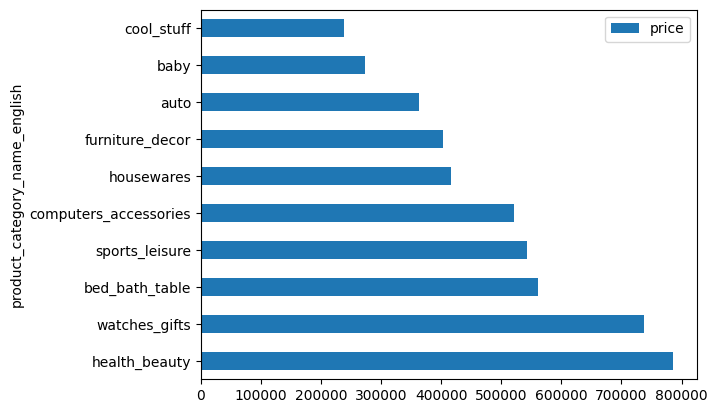

In [22]:
Sales_in_2018.groupby('product_category_name_english').agg({'price':'sum'}).sort_values(by='price',ascending=False).head(10).plot(kind='barh')

### Q4. Highest revenue generated by state in each year.

<Axes: ylabel='customer_state'>

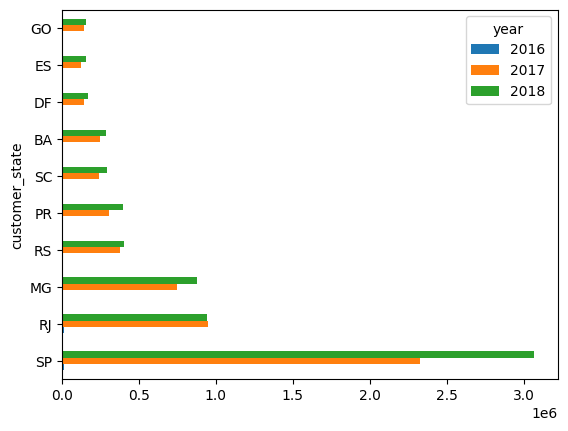

In [23]:
valid_Sales['year'] = valid_Sales['order_purchase_timestamp'].dt.year
State_Year_Sales = valid_Sales.groupby(by=['year','customer_state']).agg({'price':'sum'})
unstacked_sales = State_Year_Sales['price'].unstack(level='year')
sorted = unstacked_sales.sort_values(by=2018,ascending=False).head(10)
sorted.plot(kind='barh')

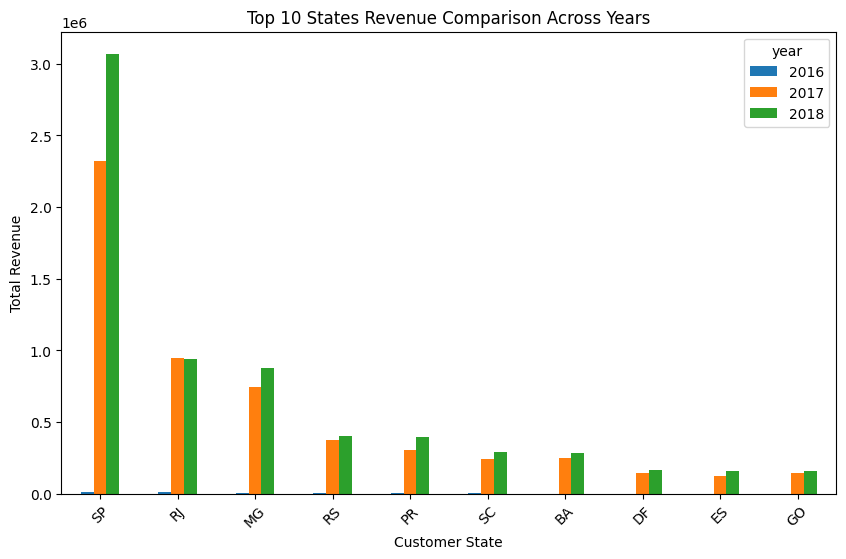

In [24]:
# 1. Group without sorting globally yet
state_year_grouped = valid_Sales.groupby(['customer_state', 'year']).agg({'price':'sum'})

# 2. Unstack the 'year' level into separate columns
unstacked_sales = state_year_grouped['price'].unstack(level='year')

# 3. Sort by total overall volume (using 2018 as a baseline) and grab the top 10
top_10_states = unstacked_sales.sort_values(by=2018, ascending=False).head(10)

# 4. Plot a beautiful side-by-side grouped bar chart
top_10_states.plot(kind='bar', figsize=(10, 6))
plt.title('Top 10 States Revenue Comparison Across Years')
plt.ylabel('Total Revenue')
plt.xlabel('Customer State')
plt.xticks(rotation=45)
plt.show()

### Q5. What is the most common payment type used by customers?

<Axes: xlabel='count', ylabel='payment_type'>

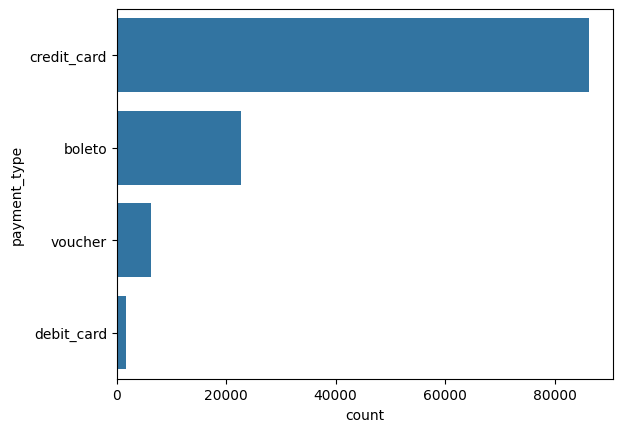

In [25]:
sns.countplot(valid_Sales['payment_type'])